In [79]:
pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 75.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 85.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.7 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.preprocessing import StandardScaler

import numpy as np
import cartopy.crs as ccrs

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import numpy as np


In [2]:
import os

directory = './Dataset'
ext = ('.grib')

file = []

for files in os.listdir(directory):
    if (files.endswith(ext)):
        file.append(files)

print(file)

['temperature_data.grib', 'data.grib', 'precipitation_data.grib', 'evap_total_cloud_2005-2024.grib', 'pressure_and_evaporation_data.grib']


In [3]:
# !pip install cfgrib
# !pip install xarray
import xarray as xr

grib_files = ['pressure_and_evaporation_data.grib',
              'temperature_data.grib',
              'evap_total_cloud_2005-2024.grib']


filePath = './Dataset/'

dataArray = []

for _, grib in enumerate(grib_files):
    # temp = xr.open_dataset(filePath + grib, engine='cfgrib')
    print(grib)
    # dataArray.append(xr.open_dataset(filePath + grib, engine='cfgrib'));
    # print(dataframes[-1].dims)
    


pressure_and_evaporation_data.grib
temperature_data.grib
evap_total_cloud_2005-2024.grib


In [24]:
grouped_nc_dict = {
    'ERA-10u': ['Dataset/ERA-10u-part1.nc', 'Dataset/ERA-10v-part2.nc'],
    'ERA-10v': ['Dataset/ERA-10v-part1.nc', 'Dataset/ERA-10v-part2.nc'],
    'sea_surface_temp': ['Dataset/sea_surface_temp_2005_2014.nc', 'Dataset/sea_surface_temp_2015_2024.nc', 'Dataset/sea_surface_temp_2025.nc'],
    'two_m_dewpoint': ['Dataset/two_m_dewpoint_2005_2014.nc', 'Dataset/two_m_dewpoint_2015_2024.nc', 'Dataset/two_m_dewpoint_2025.nc'],
    'two_m_temp': ['Dataset/two_m_temp_2005_2014.nc', 'Dataset/two_m_temp_2015-2024.nc', 'Dataset/two_m_temp_2025.nc']
}

ds_ERA_10u = xr.open_mfdataset(grouped_nc_dict['ERA-10u'], combine="by_coords", chunks={"time": 100})
ERA_10u = ds_ERA_10u
u10 = ds_ERA_10u['u10'][0, :, :]
v10 = ds_ERA_10u['v10'][0, :, :]
lon = ds_ERA_10u['longitude']
lat = ds_ERA_10u['latitude']
ds_ERA_10u.close()

In [5]:
print(lon.shape, lat.shape, u10.shape, v10.shape)

(101,) (41,) (41, 101) (41, 101)


In [6]:
u10_clean = np.nan_to_num(u10, nan=0.0)  # Replace NaN with 0
v10_clean = np.nan_to_num(v10, nan=0.0)

In [10]:
list(ERA_10u.keys())

['u10', 'v10']

In [25]:
ERA_10u['v10']

<xarray.DataArray 'v10' (valid_time: 29564, latitude: 41, longitude: 101)> Size: 490MB
dask.array<where, shape=(29564, 41, 101), dtype=float32, chunksize=(20567, 14, 34), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 237kB 2005-01-01 ... 2025-03-27T1...
  * latitude    (latitude) float64 328B 35.0 34.75 34.5 ... 25.5 25.25 25.0
  * longitude   (longitude) float64 808B -100.0 -99.75 -99.5 ... -75.25 -75.0
    number      int64 8B 0
    expver      (valid_time) object 237kB dask.array<chunksize=(29564,), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             166
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      4141
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre V wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

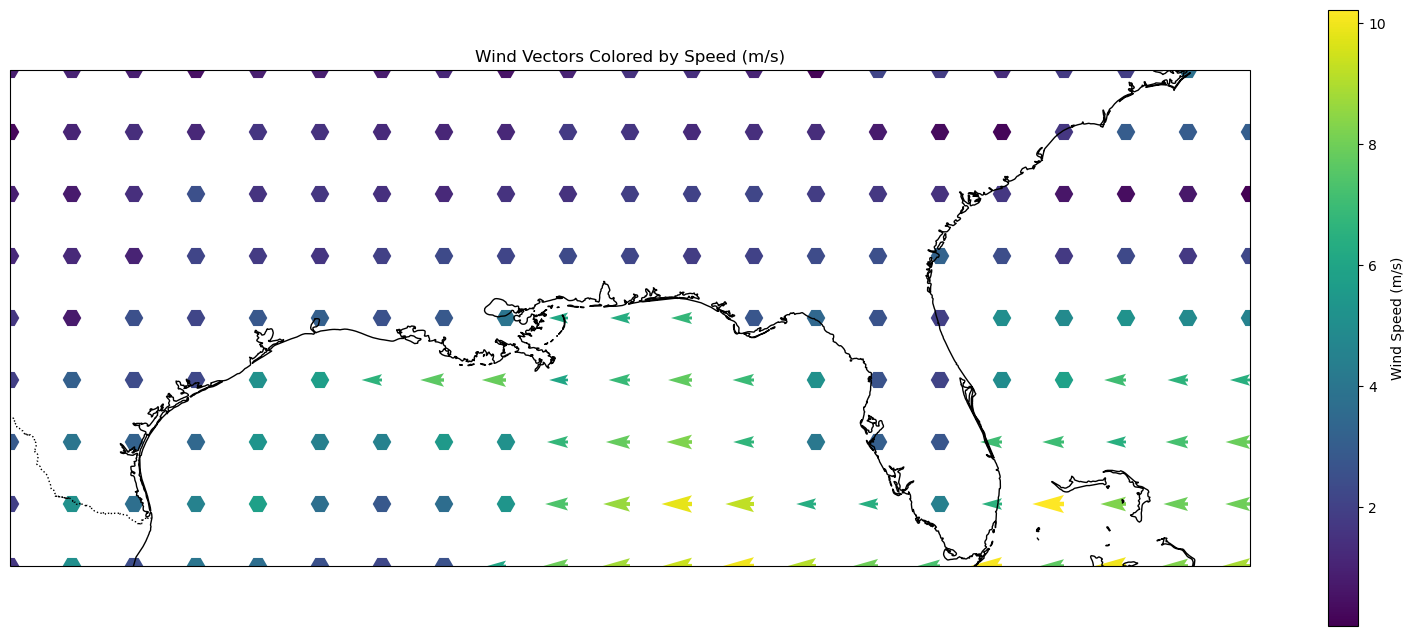

In [7]:
# Select timestep and clean data
u10_slice = u10
v10_slice = v10
u10_clean = np.nan_to_num(u10_slice, nan=0.0)
v10_clean = np.nan_to_num(v10_slice, nan=0.0)
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Calculate wind speed for coloring
wind_speed = np.sqrt(u10_clean**2 + v10_clean**2)

# Create figure
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot vectors with color mapping
stride = 5
Q = ax.quiver(
    lon_grid[::stride, ::stride],
    lat_grid[::stride, ::stride],
    u10_clean[::stride, ::stride],
    v10_clean[::stride, ::stride],
    wind_speed[::stride, ::stride],  # Color by wind speed
    scale=400,  # Adjust as needed
    width=0.015,      # Thicker shafts (default: 0.005)
    headwidth=4,      # Wider arrowheads (default: 3)
    headlength=7,     # Longer arrowheads (default: 5)
    headaxislength=6,
    transform=ccrs.PlateCarree(),
    cmap='viridis'  # Color map
)

ax.set_title("Wind Vectors Colored by Speed (m/s)")
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Add colorbar
cbar = plt.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
plt.show()

In [22]:
def make_wind_animation(u10, v10, lon, lat, plot_title, stride=5):
    # 1. Verify time dimension
    time_dim = 'time' if 'time' in u10.dims else 'valid_time'
    
    # 2. Pre-compute data
    wind_speed = np.sqrt(u10**2 + v10**2).compute()
    lon_grid, lat_grid = np.meshgrid(lon.values, lat.values)
    
    # Set color normalization based on ALL frames
    vmin, vmax = wind_speed.min().values, wind_speed.max().values
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')  # Or try 'plasma', 'magma', 'coolwarm'
    
    # 3. Set up figure with PERSISTENT features
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Create reusable feature objects
    coastline = cfeature.COASTLINE.with_scale('50m')
    borders = cfeature.BORDERS.with_scale('50m')
    
    # Add features that should NEVER be removed
    ax.add_feature(coastline, linewidth=0.8, edgecolor='black')
    ax.add_feature(borders, linewidth=0.5, edgecolor='gray', linestyle=':')
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # 4. Initialize quiver with first frame (for colorbar reference)
    Q = ax.quiver([], [], [], [], [], 
                 scale=400, width=0.015,
                 transform=ccrs.PlateCarree(),
                 cmap=cmap,
                 norm=norm)
    
    # Add colorbar (only once)
    cbar = fig.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
    #cbar.set_clim(vmin, vmax)
    
    # 5. Animation update function
    def update(frame):
        # SAFELY remove only quiver elements
        for artist in ax.collections:
            if isinstance(artist, matplotlib.quiver.Quiver):
                artist.remove()
        
        # Get current frame data
        u_frame = u10.isel({time_dim: frame}).values
        v_frame = v10.isel({time_dim: frame}).values
        speed_frame = wind_speed.isel({time_dim: frame}).values
        
        # Clean data
        u_clean = np.nan_to_num(u_frame, nan=0.0)
        v_clean = np.nan_to_num(v_frame, nan=0.0)
        speed_clean = np.nan_to_num(speed_frame, nan=0.0)
        
        # Create new quiver plot with color mapping
        Q = ax.quiver(
            lon_grid[::stride, ::stride],
            lat_grid[::stride, ::stride],
            u_clean[::stride, ::stride],
            v_clean[::stride, ::stride],
            speed_clean[::stride, ::stride],  # This maps to color
            scale=400,
            width=0.015,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm  # Use the same normalization for all frames
        )
        
        ax.set_title(f"{plot_title} - Frame {frame}")
        return Q,
    
    # 6. Create and save animation
    anim = FuncAnimation(fig, update, 
                        frames=range(0, len(u10[time_dim]), 100),
                        interval=200, 
                        blit=False)
    
    anim.save("Animation/wind_animation_colored.gif", writer="pillow", fps=4, dpi=150)
    plt.close()
    return anim

# Usage example (with proper data loading):
ds = xr.open_mfdataset(grouped_nc_dict['ERA-10u'], combine='by_coords')
u10 = ds['u10'].load()  # Force load into memory
v10 = ds['v10'].load()
lon = ds['longitude']
lat = ds['latitude']

animation = make_wind_animation(
    u10=u10,
    v10=v10,
    lon=lon,
    lat=lat,
    plot_title="Wind Vectors",
    stride=8
)

# Ignore everything below

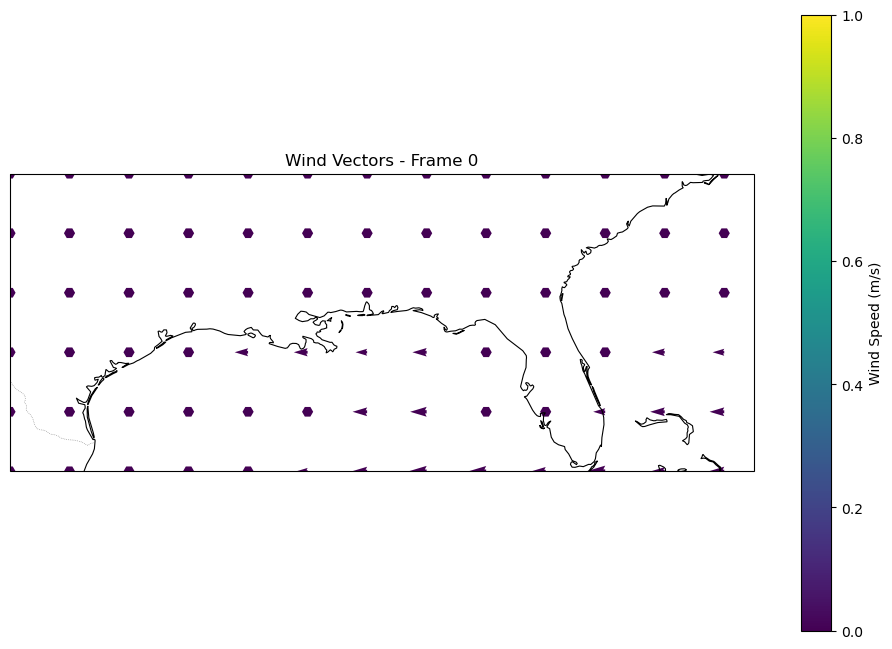

In [20]:
def make_wind_animation(u10, v10, lon, lat, plot_title, stride=5):
    # 1. Verify time dimension
    time_dim = 'time' if 'time' in u10.dims else 'valid_time'
    
    # 2. Pre-compute data
    wind_speed = np.sqrt(u10**2 + v10**2).compute()
    lon_grid, lat_grid = np.meshgrid(lon.values, lat.values)
    
    # 3. Set up figure with PERSISTENT features
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Create reusable feature objects
    coastline = cfeature.COASTLINE.with_scale('50m')
    borders = cfeature.BORDERS.with_scale('50m')
    
    # Add features that should NEVER be removed
    ax.add_feature(coastline, linewidth=0.8, edgecolor='black')
    ax.add_feature(borders, linewidth=0.5, edgecolor='gray', linestyle=':')
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # 4. Initialize quiver with first frame
    Q = ax.quiver([], [], [], [], [], 
                 scale=400, width=0.015,
                 transform=ccrs.PlateCarree(),
                 cmap='viridis')
    
    # 5. Animation update function
    def update(frame):
        # SAFELY remove only quiver elements
        for artist in ax.collections:
            if isinstance(artist, matplotlib.quiver.Quiver):
                artist.remove()
        
        # Get current frame data
        u_frame = u10.isel({time_dim: frame}).values
        v_frame = v10.isel({time_dim: frame}).values
        speed_frame = wind_speed.isel({time_dim: frame}).values
        
        # Create new quiver plot
        Q = ax.quiver(
            lon_grid[::stride, ::stride],
            lat_grid[::stride, ::stride],
            np.nan_to_num(u_frame[::stride, ::stride]),
            np.nan_to_num(v_frame[::stride, ::stride]),
            np.nan_to_num(speed_frame[::stride, ::stride]),
            scale=400,
            width=0.015,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )
        
        ax.set_title(f"{plot_title} - Frame {frame}")
        return Q,
    cbar = plt.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
    
    # 6. Create and save animation
    anim = FuncAnimation(fig, update, frames=range(0, len(u10[time_dim]), 100), interval=200, blit=False)
    anim.save("Animation/wind_animation_fixed.gif", writer="pillow", fps=4, dpi=150)
    return anim

# Usage example (with proper data loading):
ds = xr.open_mfdataset(grouped_nc_dict['ERA-10u'], combine='by_coords')
u10 = ds['u10'].load()  # Force load into memory
v10 = ds['v10'].load()
lon = ds['longitude']
lat = ds['latitude']

animation = make_wind_animation(
    u10=u10,
    v10=v10,
    lon=lon,
    lat=lat,
    plot_title="Wind Vectors",
    stride=8
)

Using time dimension: valid_time


/tmp/ipykernel_2445/2007112651.py:47: RuntimeWarning: All-NaN slice encountered
  vmin, vmax = np.nanmin(wind_speed.values), np.nanmax(wind_speed.values)


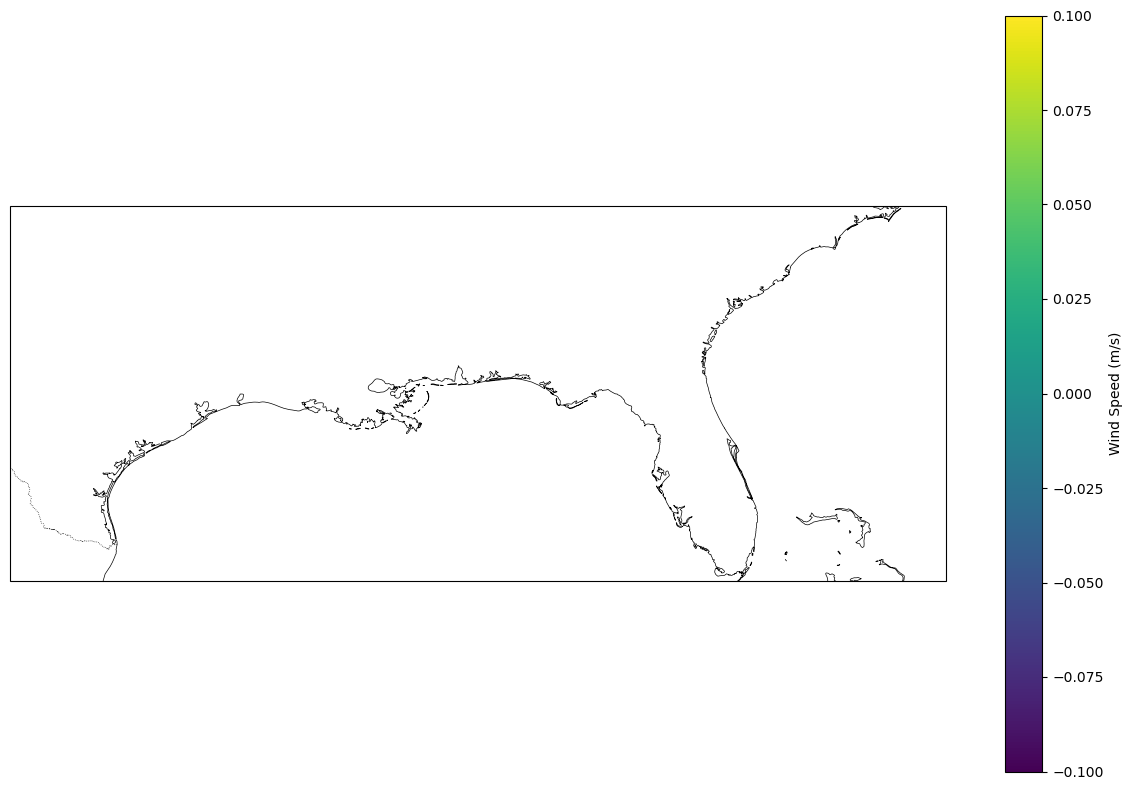

In [12]:
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

def make_wind_animation(u10, v10, lon, lat, plot_title, stride=5):
    # 1. Verify time dimension name
    time_dim = 'time' if 'time' in u10.dims else 'valid_time'
    print(f"Using time dimension: {time_dim}")
    
    # 2. Pre-compute wind speed and ensure data is loaded
    wind_speed = np.sqrt(u10**2 + v10**2).compute()  # Force load if using dask
    
    # 3. Create grid (convert to numpy arrays to avoid xarray issues)
    lon_grid, lat_grid = np.meshgrid(lon.values, lat.values)
    
    # 4. Set up figure with persistent features
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Store features that shouldn't change
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    
    # 5. Initialize with first frame to set proper scaling
    u_first = u10.isel({time_dim: 0}).values
    v_first = v10.isel({time_dim: 0}).values
    speed_first = wind_speed.isel({time_dim: 0}).values
    
    Q = ax.quiver(
        lon_grid[::stride, ::stride],
        lat_grid[::stride, ::stride],
        u_first[::stride, ::stride],
        v_first[::stride, ::stride],
        speed_first[::stride, ::stride],
        scale=400,
        width=0.015,
        transform=ccrs.PlateCarree(),
        cmap='viridis'
    )
    
    # Add colorbar with fixed range
    vmin, vmax = np.nanmin(wind_speed.values), np.nanmax(wind_speed.values)
    cbar = fig.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
    Q.set_clim(vmin, vmax)
    
    # 6. Animation update function
    def update(frame):
        # Clear only quiver elements (preserve map features)
        for coll in ax.collections:
            coll.remove()
        
        # Get current frame data (load explicitly if using dask)
        u_frame = u10.isel({time_dim: frame}).values
        v_frame = v10.isel({time_dim: frame}).values
        speed_frame = wind_speed.isel({time_dim: frame}).values
        
        # Clean data
        u_clean = np.nan_to_num(u_frame, nan=0.0)
        v_clean = np.nan_to_num(v_frame, nan=0.0)
        speed_clean = np.nan_to_num(speed_frame, nan=0.0)
        
        # Create new quiver plot
        Q = ax.quiver(
            lon_grid[::stride, ::stride],
            lat_grid[::stride, ::stride],
            u_clean[::stride, ::stride],
            v_clean[::stride, ::stride],
            speed_clean[::stride, ::stride],
            scale=400,
            width=0.015,
            headwidth=4,
            headlength=7,
            headaxislength=6,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )
        
        ax.set_title(f"{plot_title} - Frame {frame}")
        return Q,
    
    # 7. Create animation with fewer frames for testing
    #test_frames = min(10, len(u10[time_dim]))  # Test with first 10 frames
    anim = FuncAnimation(
        fig,
        update,
        frames=range(0, len(u10[time_dim]), 1000),
        interval=200,
        blit=False
    )
    
    # 8. Preview before saving
    plt.tight_layout()
    plt.show()
    
    # 9. Save only after verifying it works
    anim.save("Animation/wind_animation_debugged.gif", writer="pillow", fps=4, dpi=150)
    return anim

# Usage example (with proper data loading):
ds = xr.open_mfdataset(grouped_nc_dict['ERA-10u'], combine='by_coords')
u10 = ds['u10'].load()  # Force load into memory
v10 = ds['v10'].load()
lon = ds['longitude']
lat = ds['latitude']

animation = make_wind_animation(
    u10=u10,
    v10=v10,
    lon=lon,
    lat=lat,
    plot_title="Wind Vectors",
    stride=8
)

In [10]:
def make_wind_animation(u10, v10, lon, lat, plot_title, stride=5):
    # First check your time dimension name!
    time_dim = 'time' if 'time' in u10.dims else 'valid_time'
    
    # Calculate wind speed for coloring
    wind_speed = np.sqrt(u10**2 + v10**2)
    
    # Create grid (only once)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    # Set up figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Store these for reuse
    coast = cfeature.COASTLINE
    borders = cfeature.BORDERS#.with_args(linestyle=':')
    
    # Initial plot (empty)
    Q = ax.quiver([], [], [], [], [], 
                 scale=400, width=0.015,
                 headwidth=4, headlength=7, headaxislength=6,
                 transform=ccrs.PlateCarree(),
                 cmap='viridis')
    
    # Add permanent features
    ax.add_feature(coast)
    ax.add_feature(borders)
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    
    # Add colorbar (only once)
    cbar = fig.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
    vmin, vmax = wind_speed.min().values, wind_speed.max().values
    Q.set_clim(vmin, vmax)  # Fix color scale
    
    def update(frame):
        # Clear only the quiver (not the whole axes)
        for artist in ax.collections + ax.artists:
            artist.remove()
        
        # Re-add features
        ax.add_feature(coast)
        ax.add_feature(borders)
        
        # Get current frame data
        u_frame = u10.isel({time_dim: frame})
        v_frame = v10.isel({time_dim: frame})
        speed_frame = wind_speed.isel({time_dim: frame})
        
        # Clean data
        u_clean = np.nan_to_num(u_frame, nan=0.0)
        v_clean = np.nan_to_num(v_frame, nan=0.0)
        
        # Create new quiver plot
        Q = ax.quiver(
            lon_grid[::stride, ::stride],
            lat_grid[::stride, ::stride],
            u_clean[::stride, ::stride],
            v_clean[::stride, ::stride],
            speed_frame[::stride, ::stride],
            scale=400,
            width=0.015,
            headwidth=4,
            headlength=7,
            headaxislength=6,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )
        
        ax.set_title(f"{' '.join(plot_title)} - Time Step {frame}")
        return Q,
    
    # Create animation
    anim = FuncAnimation(
        fig, 
        update,
        frames=range(0, len(u10[time_dim]), 1000),  # Use all frames
        interval=200,
        blit=False,
        repeat=False
    )
    
    # Save animation
    anim.save("wind_animation.gif", writer="pillow", fps=5, dpi=150)
    plt.close()
    return anim

In [13]:
# First ensure your data is properly loaded
ds_ERA_10u = xr.open_mfdataset(grouped_nc_dict['ERA-10u'], combine="by_coords", chunks={"time": 100})
u10 = ds_ERA_10u['u10']
v10 = ds_ERA_10u['v10']
lon = ds_ERA_10u['longitude']
lat = ds_ERA_10u['latitude']

# Then create animation
animation = make_wind_animation(
    u10=u10, 
    v10=v10, 
    lon=lon, 
    lat=lat, 
    plot_title=["Wind", "Vectors"],
    stride=5
)

# Don't close the dataset until after animation is complete
ds_ERA_10u.close()

In [ ]:
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import numpy as np

def make_wind_animation(u10, v10, lon, lat, plot_title, stride=5):
    # Calculate wind speed for coloring
    wind_speed = np.sqrt(u10**2 + v10**2)
    
    # Create grid
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    # Set up figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    
    # Initialize empty quiver plot
    Q = ax.quiver([], [], [], [], [], 
                 scale=100, width=0.015, 
                 transform=ccrs.PlateCarree(),
                 cmap='viridis')
    
    # Add colorbar
    cbar = fig.colorbar(Q, ax=ax, label='Wind Speed (m/s)')
    
    def update(frame):
        ax.clear()
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        
        # Get data for current frame
        u_frame = u10.isel(valid_time=frame)
        v_frame = v10.isel(valid_time=frame)
        speed_frame = wind_speed.isel(valid_time=frame)
        
        # Clean NaN values
        u_clean = np.nan_to_num(u_frame, nan=0.0)
        v_clean = np.nan_to_num(v_frame, nan=0.0)
        
        # Create new quiver plot
        stride = 5
        Q = ax.quiver(
            lon_grid[::stride, ::stride],
            lat_grid[::stride, ::stride],
            u_clean[::stride, ::stride],
            v_clean[::stride, ::stride],
            speed_frame[::stride, ::stride],
            scale=400,
            width=0.015,
            headwidth=4,      # Wider arrowheads (default: 3)
            headlength=7,     # Longer arrowheads (default: 5)
            headaxislength=6,
            transform=ccrs.PlateCarree(),
            cmap='viridis'
        )
        
        ax.set_title(f"{' '.join(plot_title)} - Time Step {frame}")
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
        return Q,
    
    # Create animation (using every 10th time step for efficiency)
    anim = FuncAnimation(fig, update, 
                        frames=range(0, len(ERA_10u.valid_time), 1000),  # Adjust step as needed
                        interval=200, 
                        blit=False)
    
    # Save as GIF
    anim.save(f"Animation/wind_animation.gif", writer="pillow", fps=5, dpi=100)
    plt.close()
    return anim

In [8]:
# Assuming u10, v10 are your xarray DataArrays with time dimension
animation = make_wind_animation(
    u10=u10, 
    v10=v10, 
    lon=lon, 
    lat=lat, 
    plot_title=["Wind", "Vectors"],
    stride=5  # Adjust for arrow density
)

In [59]:
def make_animation(var, plot_title, colors):
    fig, ax = plt.subplots(figsize=(10, 6))

    plot = var.isel(time=0).plot(ax=ax, cmap=colors, add_colorbar=True)
    title = ax.set_title(f"{' '.join(plot_title)} at Time Step 0")
    
    def update(frame):
        ax.clear()
        plot = var.isel(time=frame).plot(ax=ax, cmap=colors, add_colorbar=False)
        ax.set_title(f"{' '.join(plot_title)} at Time Step {frame}")
        return plot
        
    anim = FuncAnimation(fig, update, frames=range(0, len(var.time), 100), interval=200)
    anim.save(f"Animation/{'_'.join(plot_title)}_animation_2.gif", writer="pillow", fps=5) 
    plt.show()